## PyTorch简介

> 本笔记本是[AI for Beginners Curricula](http://github.com/microsoft/ai-for-beginners)的一部分。访问该仓库以获取完整的学习资料。

### 神经网络框架

我们已经了解到，训练神经网络需要以下内容：
* 快速进行矩阵（张量）运算
* 计算梯度以执行梯度下降优化

神经网络框架可以让你做到以下事情：
* 在可用的计算设备上操作张量，无论是CPU、GPU，甚至是TPU
* 自动计算梯度（所有内置张量函数都显式编程支持）

可选功能：
* 神经网络构造器/高级API（将网络描述为一系列层）
* 简单的训练函数（如Scikit Learn中的`fit`）
* 除梯度下降外的多种优化算法
* 数据处理抽象（理想情况下也能在GPU上运行）


### 最受欢迎的框架

* Tensorflow 1.x - 第一个广泛使用的框架（Google）。允许定义静态计算图，将其推送到GPU，并显式进行评估
* PyTorch - 来自Facebook的框架，越来越受欢迎
* Keras - 基于Tensorflow/PyTorch的高级API，用于统一和简化神经网络的使用（Francois Chollet）
* Tensorflow 2.x + Keras - 新版Tensorflow，集成了Keras功能，支持**动态计算图**，可以进行类似numpy（以及PyTorch）的张量操作

在这个Notebook中，我们将学习如何使用PyTorch。请确保您安装了最新版本的PyTorch——具体操作请参考[他们网站上的说明](https://pytorch.org/get-started/locally/)。通常只需执行以下命令：
```
pip install torch torchvision
```
或者
```
conda install pytorch -c pytorch
```


In [1]:
import torch
torch.__version__

'2.5.1'

## 基本概念：张量

**张量** 是一种多维数组。使用张量来表示不同类型的数据非常方便：
* 400x400 - 黑白图片
* 400x400x3 - 彩色图片
* 16x400x400x3 - 包含16张彩色图片的小批量
* 25x400x400x3 - 一秒钟的25帧视频
* 8x25x400x400x3 - 包含8个1秒视频的小批量


### 简单张量

你可以轻松地通过 np-array 列表创建简单的张量，或者生成随机张量：


In [4]:
a = torch.tensor([[1,2],[3,4]])
print(a)
a = torch.randn(size=(10,3))
print(a)

tensor([[1, 2],
        [3, 4]])
tensor([[ 0.1522, -0.5468, -0.3888],
        [-1.4183, -0.8153, -0.2603],
        [ 1.5693, -0.7612,  0.4288],
        [-2.2106, -0.1574, -0.2920],
        [ 1.1291,  0.1139,  1.6404],
        [ 2.2624, -0.4622, -0.0340],
        [ 0.4409, -0.1874, -0.5390],
        [-0.4902, -1.0755,  1.6694],
        [ 0.3572, -1.5816, -1.3557],
        [ 0.3958, -1.3256, -0.2118]])


您可以对张量进行算术运算，这些运算是逐元素执行的，就像在 numpy 中一样。如果需要，张量会自动扩展到所需的维度。要从张量中提取 numpy 数组，请使用 `.numpy()`：


In [ ]:
print(a-a[0])
print(torch.exp(a)[0].numpy())

tensor([[ 0.0000,  0.0000,  0.0000],
        [-2.0583, -0.5631,  1.4932],
        [-1.0613, -1.0738,  2.2078],
        [-1.5101,  0.5896,  2.4722],
        [-2.8219, -2.0846,  1.2405],
        [ 0.8706, -0.2485,  2.3679],
        [-1.6590,  0.1935,  1.8698],
        [-0.3316,  0.8065,  1.6490],
        [-1.5788, -1.1844, -0.4816],
        [ 0.0680, -1.4526,  1.8159]])
[3.887189   2.1276016  0.17371987]


## 原地操作和非原地操作

像 `+`/`add` 这样的张量操作会返回新的张量。然而，有时你需要直接修改现有的张量。大多数操作都有对应的原地版本，这些操作以 `_` 结尾：


In [2]:
u = torch.tensor(5)
print("Result when adding out-of-place:",u.add(torch.tensor(3)))
u.add_(torch.tensor(3))
print("Result after adding in-place:", u)

Result when adding out-of-place: tensor(8)
Result after adding in-place: tensor(8)


这是我们以一种简单方式计算矩阵中所有行的总和的方法：


In [5]:
s = torch.zeros_like(a[0])
for i in a:
  s.add_(i)

print(s)

tensor([ 2.1877, -6.7990,  0.6571])


但更好的是使用


In [6]:
torch.sum(a,axis=0)

tensor([ 2.1877, -6.7990,  0.6571])

你可以在[官方文档](https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html)中阅读更多关于PyTorch张量的内容


## 计算梯度

为了进行反向传播，你需要计算梯度。我们可以将任意 PyTorch Tensor 的属性 `requires_grad` 设置为 `True`，这样与该张量相关的所有操作都会被跟踪，用于梯度计算。要计算梯度，你需要调用 `backward()` 方法，之后可以通过 `grad` 属性获取梯度：


In [7]:
a = torch.randn(size=(2, 2), requires_grad=True)
b = torch.randn(size=(2, 2))

c = torch.mean(torch.sqrt(torch.square(a) + torch.square(b)))  # Do some math using `a`
c.backward() # call backward() to compute all gradients
# What's the gradient of `c` with respect to `a`?
print(a.grad)

tensor([[ 0.0669,  0.0209],
        [ 0.1801, -0.0281]])


为了更精确地说，PyTorch 会自动**累积**梯度。如果在调用 `backward` 时指定 `retain_graph=True`，计算图将被保留，并且新的梯度会被添加到 `grad` 字段中。为了从头开始重新计算梯度，我们需要通过调用 `zero_()` 显式地将 `grad` 字段重置为 0：


In [11]:
c = torch.mean(torch.sqrt(torch.square(a) + torch.square(b)))
c.backward(retain_graph=True)
print(a.grad)
c.backward(retain_graph=True)
print(a.grad)
a.grad.zero_()
c.backward()
print(a.grad)

tensor([[ 0.1338,  0.0418],
        [ 0.3603, -0.0563]])
tensor([[ 0.2008,  0.0626],
        [ 0.5404, -0.0844]])
tensor([[ 0.0669,  0.0209],
        [ 0.1801, -0.0281]])


为了计算梯度，PyTorch 创建并维护**计算图**。对于每个 `requires_grad` 标志设置为 `True` 的张量，PyTorch 维护一个名为 `grad_fn` 的特殊函数，该函数根据链式求导法则计算表达式的导数：


比如loss1和loss2计算图一样时，就不能删除计算图。


In [ ]:
print(c)

tensor(0.9143, grad_fn=<MeanBackward0>)


这里的 `c` 是通过 `mean` 函数计算的，因此 `grad_fn` 指向一个名为 `MeanBackward` 的函数。

在大多数情况下，我们希望 PyTorch 计算标量函数（例如损失函数）的梯度。然而，如果我们想计算一个张量相对于另一个张量的梯度，PyTorch 允许我们计算雅可比矩阵与给定向量的乘积。

假设我们有一个向量函数 $\vec{y}=f(\vec{x})$，其中
$\vec{x}=\langle x_1,\dots,x_n\rangle$ 且
$\vec{y}=\langle y_1,\dots,y_m\rangle$，那么 $\vec{y}$ 相对于 $\vec{x}$ 的梯度由 **雅可比矩阵** 定义：

$$
\begin{align}J=\left(\begin{array}{ccc}
   \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{1}}{\partial x_{n}}\\
   \vdots & \ddots & \vdots\\
   \frac{\partial y_{m}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
\end{array}\right)\end{align}
$$

PyTorch 并不会直接提供整个雅可比矩阵，而是计算雅可比矩阵与某个向量 $v=(v_1 \dots v_m)$ 的乘积 $v^T\cdot J$。为了实现这一点，我们需要调用 ``backward`` 并将 `v` 作为参数传入。`v` 的大小应与我们计算梯度时的原始张量大小一致。


In [ ]:
c = torch.sqrt(torch.square(a) + torch.square(b))
c.backward(torch.eye(2)) # eye(2) means 2x2 identity matrix
print(a.grad)

tensor([[-0.8642,  0.0913],
        [-0.1666, -0.9710]])


在 PyTorch 中计算雅可比矩阵的更多信息可以在[官方文档](https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html)中找到


# 示例 0：使用梯度下降进行优化

我们尝试使用自动微分来找到一个简单的二元函数 $f(x_1,x_2)=(x_1-3)^2+(x_2+2)^2$ 的最小值。让张量 `x` 保存一个点的当前坐标。我们从起始点 $x^{(0)}=(0,0)$ 开始，并使用梯度下降公式计算序列中的下一个点：
$$
x^{(n+1)} = x^{(n)} - \eta\nabla f
$$
这里 $\eta$ 是所谓的**学习率**（在代码中我们用 `lr` 表示），而 $\nabla f = (\frac{\partial f}{\partial x_1},\frac{\partial f}{\partial x_2})$ 是 $f$ 的梯度。

首先，让我们定义 `x` 的初始值和函数 `f`：


In [ ]:
x = torch.zeros(2,requires_grad=True)
f = lambda x : (x-torch.tensor([3,-2])).pow(2).sum()
lr = 0.1

现在让我们进行15次梯度下降迭代。在每次迭代中，我们将更新`x`坐标并打印它们，以确保我们正在接近最低点(3,-2)：


In [ ]:
for i in range(15):
    y = f(x)
    y.backward()
    gr = x.grad
    x.data.add_(-lr*gr)
    x.grad.zero_()
    print("Step {}: x[0]={}, x[1]={}".format(i,x[0],x[1]))

Step 0: x[0]=0.6000000238418579, x[1]=-0.4000000059604645
Step 1: x[0]=1.0800000429153442, x[1]=-0.7200000286102295
Step 2: x[0]=1.4639999866485596, x[1]=-0.9760000705718994
Step 3: x[0]=1.7711999416351318, x[1]=-1.1808000802993774
Step 4: x[0]=2.0169599056243896, x[1]=-1.3446400165557861
Step 5: x[0]=2.2135679721832275, x[1]=-1.4757120609283447
Step 6: x[0]=2.370854377746582, x[1]=-1.5805696249008179
Step 7: x[0]=2.4966835975646973, x[1]=-1.6644556522369385
Step 8: x[0]=2.597346782684326, x[1]=-1.7315645217895508
Step 9: x[0]=2.677877426147461, x[1]=-1.7852516174316406
Step 10: x[0]=2.7423019409179688, x[1]=-1.8282012939453125
Step 11: x[0]=2.793841600418091, x[1]=-1.8625609874725342
Step 12: x[0]=2.835073232650757, x[1]=-1.8900487422943115
Step 13: x[0]=2.868058681488037, x[1]=-1.912039041519165
Step 14: x[0]=2.894446849822998, x[1]=-1.929631233215332


## 示例 1：线性回归

现在我们已经掌握了足够的知识来解决经典的**线性回归**问题。让我们生成一个小型的合成数据集：


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
import random

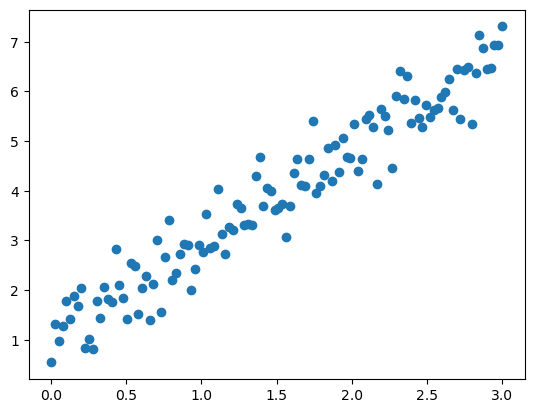

In [13]:
np.random.seed(13) # pick the seed for reproducibility - change it to explore the effects of random variations

train_x = np.linspace(0, 3, 120)
train_labels = 2 * train_x + 0.9 + np.random.randn(*train_x.shape) * 0.5

plt.scatter(train_x,train_labels)

线性回归由一条直线 $f_{W,b}(x) = Wx+b$ 定义，其中 $W, b$ 是我们需要找到的模型参数。我们数据集上的误差 $\{x_i,y_i\}_{i=1}^N$（也称为**损失函数**）可以定义为均方误差：
$$
\mathcal{L}(W,b) = {1\over N}\sum_{i=1}^N (f_{W,b}(x_i)-y_i)^2
$$

让我们定义我们的模型和损失函数：


In [14]:
input_dim = 1
output_dim = 1
learning_rate = 0.1

# This is our weight matrix
w = torch.tensor([100.0],requires_grad=True,dtype=torch.float32)
# This is our bias vector
b = torch.zeros(size=(output_dim,),requires_grad=True)

def f(x):
  return torch.matmul(x,w) + b

def compute_loss(labels, predictions):
  return torch.mean(torch.square(labels - predictions))

我们将通过一系列小批量数据来训练模型。我们将使用梯度下降法，根据以下公式调整模型参数：  
$$
\begin{array}{l}
W^{(n+1)}=W^{(n)}-\eta\frac{\partial\mathcal{L}}{\partial W} \\
b^{(n+1)}=b^{(n)}-\eta\frac{\partial\mathcal{L}}{\partial b} \\
\end{array}
$$


In [15]:
def train_on_batch(x, y):
  predictions = f(x)
  loss = compute_loss(y, predictions)
  loss.backward()
  w.data.sub_(learning_rate * w.grad)
  b.data.sub_(learning_rate * b.grad)
  w.grad.zero_()
  b.grad.zero_()
  return loss

让我们进行训练。我们将多次遍历数据集（所谓的**epochs**），将其分成小批量并调用上面定义的函数：


In [16]:
# Shuffle the data.
indices = np.random.permutation(len(train_x))#返回从0-n-1的打乱数组
features = torch.tensor(train_x[indices],dtype=torch.float32)
labels = torch.tensor(train_labels[indices],dtype=torch.float32)

In [17]:
batch_size = 4
for epoch in range(10):
  for i in range(0,len(features),batch_size):
    loss = train_on_batch(features[i:i+batch_size].view(-1,1),#通过view来改变形状
  print('Epoch %d: last batch loss = %.4f' % (epoch, float(loss)))

Epoch 0: last batch loss = 94.5247
Epoch 1: last batch loss = 9.3428
Epoch 2: last batch loss = 1.4166
Epoch 3: last batch loss = 0.5224
Epoch 4: last batch loss = 0.3807
Epoch 5: last batch loss = 0.3495
Epoch 6: last batch loss = 0.3413
Epoch 7: last batch loss = 0.3390
Epoch 8: last batch loss = 0.3384
Epoch 9: last batch loss = 0.3382


我们现在已经获得了优化后的参数 $W$ 和 $b$。注意，它们的值与生成数据集时使用的原始值相似（$W=2, b=1$）。


In [18]:
`1  w,b

(tensor([1.8617], requires_grad=True), tensor([1.0711], requires_grad=True))

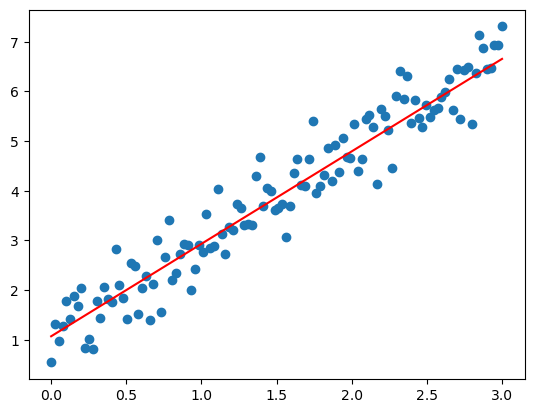

In [19]:
plt.scatter(train_x,train_labels)
x = np.array([min(train_x),max(train_x)])
with torch.no_grad():
  y = w.numpy()*x+b.numpy()
plt.plot(x,y,color='red')

## 在 GPU 上进行计算

为了在 GPU 上进行计算，PyTorch 支持将张量移动到 GPU 并为 GPU 构建计算图。通常，在代码的开头，我们会定义可用的计算设备 `device`（可以是 `cpu` 或 `cuda`），然后通过调用 `.to(device)` 将所有张量移动到该设备上。我们也可以在创建张量时直接指定设备，通过在张量创建代码中传递参数 `device=...` 来实现。这种代码在 CPU 和 GPU 上都可以无需修改地运行：


In [20]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Doing computations on '+device)

### Changes here: indicate device
w = torch.tensor([100.0],requires_grad=True,dtype=torch.float32,device=device)
b = torch.zeros(size=(output_dim,),requires_grad=True,device=device)

def f(x):
  return torch.matmul(x,w) + b

def compute_loss(labels, predictions):
  return torch.mean(torch.square(labels - predictions))

def train_on_batch(x, y):
  predictions = f(x)
  loss = compute_loss(y, predictions)
  loss.backward()
  w.data.sub_(learning_rate * w.grad)
  b.data.sub_(learning_rate * b.grad)
  w.grad.zero_()
  b.grad.zero_()
  return loss

batch_size = 4
for epoch in range(10):
  for i in range(0,len(features),batch_size):
    ### Changes here: move data to required device
    loss = train_on_batch(features[i:i+batch_size].view(-1,1).to(device),labels[i:i+batch_size].to(device))
  print('Epoch %d: last batch loss = %.4f' % (epoch, float(loss)))

Doing computations on cpu
Epoch 0: last batch loss = 94.5247
Epoch 1: last batch loss = 9.3428
Epoch 2: last batch loss = 1.4166
Epoch 3: last batch loss = 0.5224
Epoch 4: last batch loss = 0.3807
Epoch 5: last batch loss = 0.3495
Epoch 6: last batch loss = 0.3413
Epoch 7: last batch loss = 0.3390
Epoch 8: last batch loss = 0.3384
Epoch 9: last batch loss = 0.3382


## 示例 2：分类

现在我们来考虑一个二分类问题。一个很好的例子是根据肿瘤的大小和年龄来区分恶性和良性。

核心模型与回归类似，但我们需要使用不同的损失函数。让我们从生成样本数据开始：


In [21]:
np.random.seed(0) # pick the seed for reproducibility - change it to explore the effects of random variations

n = 100
X, Y = make_classification(n_samples = n, n_features=2,
                           n_redundant=0, n_informative=2, flip_y=0.1,class_sep=1.5)
X = X.astype(np.float32)
Y = Y.astype(np.int32)

split = [ 70*n//100, (15+70)*n//100 ]
train_x, valid_x, test_x = np.split(X, split)
train_labels, valid_labels, test_labels = np.split(Y, split)

In [22]:
def plot_dataset(features, labels, W=None, b=None):
    # prepare the plot
    fig, ax = plt.subplots(1, 1)
    ax.set_xlabel(r'$x_i[0]$ -- (feature 1)')
    ax.set_ylabel(r'$x_i[1]$ -- (feature 2)')
    colors = ['r' if l else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=100, alpha = 0.5)
    if W is not None:
        min_x = min(features[:,0])
        max_x = max(features[:,1])
        min_y = min(features[:,1])*(1-.1)
        max_y = max(features[:,1])*(1+.1)
        cx = np.array([min_x,max_x],dtype=np.float32)
        cy = (0.5-W[0]*cx-b)/W[1]
        ax.plot(cx,cy,'g')
        ax.set_ylim(min_y,max_y)
    fig.show()

C:\Users\huawei\AppData\Local\Temp\ipykernel_4228\3327857748.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


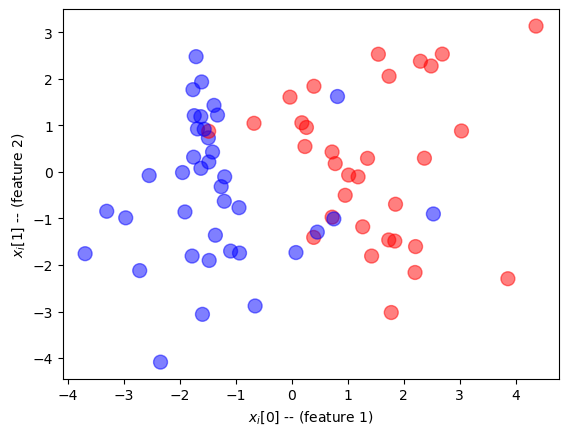

In [23]:
plot_dataset(train_x, train_labels)

## 训练单层感知机

让我们使用 PyTorch 的梯度计算机制来训练单层感知机。

我们的神经网络将有两个输入和一个输出。权重矩阵 $W$ 的尺寸为 $2\times1$，偏置向量 $b$ 的尺寸为 $1$。

为了让代码更有结构性，我们将所有参数归类到一个单独的类中：


In [24]:
class Network():
  def __init__(self):
     self.W = torch.randn(size=(2,1),requires_grad=True)
     self.b = torch.zeros(size=(1,),requires_grad=True)

  def forward(self,x):
    return torch.matmul(x,self.W)+self.b

  def zero_grad(self):
    self.W.data.zero_()
    self.b.data.zero_()

  def update(self,lr=0.1):
    self.W.data.sub_(lr*self.W.grad)
    self.b.data.sub_(lr*self.b)

net = Network()

> 注意，我们使用 `W.data.zero_()` 而不是 `W.zero_()`。我们需要这样做，因为无法直接修改通过 *Autograd* 机制跟踪的张量。

核心模型与之前的例子相同，但损失函数将是逻辑损失。为了应用逻辑损失，我们需要将网络输出的值转换为**概率**，即需要通过 `sigmoid` 激活函数将输出 $z$ 映射到 [0,1] 范围内：$p=\sigma(z)$。

如果我们得到第 i 个输入值对应的实际类别 $y_i\in\{0,1\}$ 的概率 $p_i$，损失计算公式为 $\mathcal{L_i}=-(y_i\log p_i + (1-y_i)\log(1-p_i))$。

在 PyTorch 中，这两个步骤（应用 sigmoid 和逻辑损失）可以通过调用 `binary_cross_entropy_with_logits` 函数一次性完成。由于我们在小批量中训练网络，因此需要对小批量中的所有元素的损失进行平均——这也可以通过 `binary_cross_entropy_with_logits` 函数自动完成：

> 调用 `binary_crossentropy_with_logits` 等同于先调用 `sigmoid`，然后调用 `binary_crossentropy`


In [27]:
def train_on_batch(net, x, y):
  z = net.forward(x).flatten()
  #因为这里是二分类，所以z(n，1)，flatten使得变为(n,),与y形状相同
  loss = torch.nn.functional.binary_cross_entropy_with_logits(input=z,target=y)
  net.zero_grad()
  loss.backward()
  net.update()
  return loss

为了遍历我们的数据，我们将使用 PyTorch 内置的管理数据集的机制。它基于两个概念：
* **Dataset** 是数据的主要来源，可以是 **Iterable** 或 **Map-style** 类型。
* **Dataloader** 负责从数据集中加载数据并将其分割成小批量。

在我们的例子中，我们将基于一个张量定义一个数据集，并将其分割成每批包含 16 个元素的小批量。每个小批量包含两个张量，输入数据（大小为 16x2）和标签（一个长度为 16 的整数类型向量 - 类别编号）。


In [28]:
# Create a tf.data.Dataset object for easy batched iteration
dataset = torch.utils.data.TensorDataset(torch.tensor(train_x),torch.tensor(train_labels,dtype=torch.float32))
dataloader = torch.utils.data.DataLoader(dataset,batch_size=16)

list(dataloader)[0]

[tensor([[ 1.5442,  2.5290],
         [-1.6284,  0.0772],
         [-1.7141,  2.4770],
         [-1.4951,  0.7320],
         [-1.6899,  0.9243],
         [-0.9474, -0.7681],
         [ 3.8597, -2.2951],
         [-1.3944,  1.4300],
         [ 4.3627,  3.1333],
         [-1.0973, -1.7011],
         [-2.5532, -0.0777],
         [-1.2661, -0.3167],
         [ 0.3921,  1.8406],
         [ 2.2091, -1.6045],
         [ 1.8383, -1.4861],
         [ 0.7173, -0.9718]]),
 tensor([1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1.])]

现在我们可以遍历整个数据集来训练我们的网络15个周期：


In [29]:
for epoch in range(15):
  for (x, y) in dataloader:
    loss = train_on_batch(net,x,y)
  print('Epoch %d: last batch loss = %.4f' % (epoch, float(loss)))

Epoch 0: last batch loss = 0.5691
Epoch 1: last batch loss = 0.4663
Epoch 2: last batch loss = 0.4031
Epoch 3: last batch loss = 0.3601
Epoch 4: last batch loss = 0.3287
Epoch 5: last batch loss = 0.3047
Epoch 6: last batch loss = 0.2855
Epoch 7: last batch loss = 0.2699
Epoch 8: last batch loss = 0.2568
Epoch 9: last batch loss = 0.2456
Epoch 10: last batch loss = 0.2359
Epoch 11: last batch loss = 0.2274
Epoch 12: last batch loss = 0.2199
Epoch 13: last batch loss = 0.2132
Epoch 14: last batch loss = 0.2072


获得的参数：


In [30]:
print(net.W,net.b)

tensor([[1.3867],
        [0.3529]], requires_grad=True) tensor([0.], requires_grad=True)


为了确保我们的训练有效，让我们绘制出分隔两类的直线。分隔线由方程 $W\times x + b = 0.5$ 定义。


C:\Users\huawei\AppData\Local\Temp\ipykernel_4228\3327857748.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


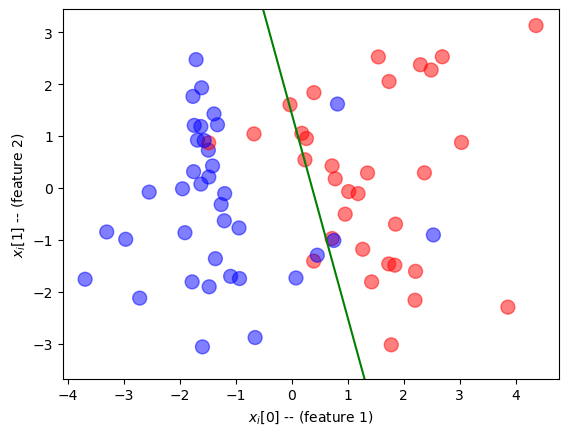

In [31]:
plot_dataset(train_x,train_labels,net.W.detach().numpy(),net.b.detach().numpy())#从计算图分离

In [32]:
pred = torch.sigmoid(net.forward(torch.tensor(valid_x)))
torch.mean(((pred.view(-1)>0.5)==(torch.tensor(valid_labels)>0.5)).type(torch.float32))

tensor(0.8000)

让我们来解释这里发生了什么：

* `pred` 是整个验证数据集的预测概率向量。我们通过将原始验证数据 `valid_x` 输入到我们的网络中，并应用 `sigmoid` 函数来计算概率。
* `pred.view(-1)` 创建了一个原始张量的扁平化视图。`view` 类似于 numpy 中的 `reshape` 函数。
* `pred.view(-1)>0.5` 返回一个布尔张量或真值，显示预测的类别（False = 类别 0，True = 类别 1）。
* 同样地，`torch.tensor(valid_labels)>0.5` 创建了验证标签的布尔张量真值。
* 我们对这两个张量逐元素进行比较，得到另一个布尔张量，其中 `True` 表示预测正确，`False` 表示预测错误。
* 我们将该张量转换为浮点数，并使用 `torch.mean` 计算其平均值——这就是我们想要的准确率。


## 神经网络和优化器

在 PyTorch 中，一个特殊的模块 `torch.nn.Module` 被定义用来表示神经网络。你可以通过以下两种方法定义自己的神经网络：
* **Sequential**，只需指定组成网络的层列表
* 继承自 `torch.nn.Module` 的 **类**

第一种方法适用于定义由层顺序组成的标准网络，而第二种方法更灵活，可以表达任意复杂架构的网络。

在模块中，你可以使用标准的 **层**，例如：
* `Linear` - 密集线性层，相当于单层感知机。它的架构与我们之前为网络定义的架构相同
* `Softmax`、`Sigmoid`、`ReLU` - 对应激活函数的层
* 还有其他用于特殊网络类型的层，例如卷积层、循环层等。我们将在课程后续部分详细讨论它们。

> PyTorch 中的大多数激活函数和损失函数都以两种形式提供：作为 **函数**（在 `torch.nn.functional` 命名空间中）和 **作为层**（在 `torch.nn` 命名空间中）。对于激活函数，通常更方便使用 `torch.nn.functional` 中的函数形式，而无需创建单独的层对象。

如果我们想训练一个单层感知机，只需使用一个内置的 `Linear` 层即可：


In [34]:
net = torch.nn.Linear(2,1) # 2 inputs, 1 output

print(list(net.parameters()))

[Parameter containing:
tensor([[-0.4558, -0.3790]], requires_grad=True), Parameter containing:
tensor([-0.5674], requires_grad=True)]


正如你所看到的，`parameters()` 方法返回了所有在训练过程中需要调整的参数。它们对应于权重矩阵 $W$ 和偏置 $b$。你可能注意到它们的 `requires_grad` 属性被设置为 `True`，因为我们需要根据这些参数计算梯度。

PyTorch 还包含内置的**优化器**，它实现了诸如**梯度下降**等优化方法。以下是我们如何定义一个**随机梯度下降优化器**的方式：


In [35]:
optim = torch.optim.SGD(net.parameters(),lr=0.05)

使用优化器后，我们的训练循环将如下所示：


In [36]:
val_x = torch.tensor(valid_x)
val_lab = torch.tensor(valid_labels)

for ep in range(10):
  for (x,y) in dataloader:
    z = net(x).flatten()
    loss = torch.nn.functional.binary_cross_entropy_with_logits(z,y)
    optim.zero_grad()
    loss.backward()
    optim.step()
  acc = ((torch.sigmoid(net(val_x).flatten())>0.5).float()==val_lab).float().mean()
  print(f"Epoch {ep}: last batch loss = {loss}, val acc = {acc}")

Epoch 0: last batch loss = 0.8009724617004395, val acc = 0.4000000059604645
Epoch 1: last batch loss = 0.677617073059082, val acc = 0.46666666865348816
Epoch 2: last batch loss = 0.5875382423400879, val acc = 0.5333333611488342
Epoch 3: last batch loss = 0.5214646458625793, val acc = 0.7333333492279053
Epoch 4: last batch loss = 0.4719982147216797, val acc = 0.7333333492279053
Epoch 5: last batch loss = 0.43389204144477844, val acc = 0.800000011920929
Epoch 6: last batch loss = 0.4036671221256256, val acc = 0.800000011920929
Epoch 7: last batch loss = 0.37906375527381897, val acc = 0.8666666746139526
Epoch 8: last batch loss = 0.3585946261882782, val acc = 0.8666666746139526
Epoch 9: last batch loss = 0.34125348925590515, val acc = 0.8666666746139526


您可能会注意到，为了将网络应用于输入数据，我们可以使用 `net(x)` 而不是 `net.forward(x)`，因为 `nn.Module` 实现了 Python 的 `__call__()` 函数。

考虑到这一点，我们可以定义一个通用的 `train` 函数：


Epoch 0: last batch loss = 0.9097052216529846, val acc = 0.4000000059604645
Epoch 1: last batch loss = 0.7972639203071594, val acc = 0.46666666865348816
Epoch 2: last batch loss = 0.6970152854919434, val acc = 0.5333333611488342
Epoch 3: last batch loss = 0.6110129952430725, val acc = 0.6666666865348816
Epoch 4: last batch loss = 0.5399613976478577, val acc = 0.6666666865348816
Epoch 5: last batch loss = 0.48282667994499207, val acc = 0.7333333492279053
Epoch 6: last batch loss = 0.4372176229953766, val acc = 0.800000011920929
Epoch 7: last batch loss = 0.400358110666275, val acc = 0.800000011920929
Epoch 8: last batch loss = 0.3699122667312622, val acc = 0.800000011920929
Epoch 9: last batch loss = 0.34425315260887146, val acc = 0.800000011920929


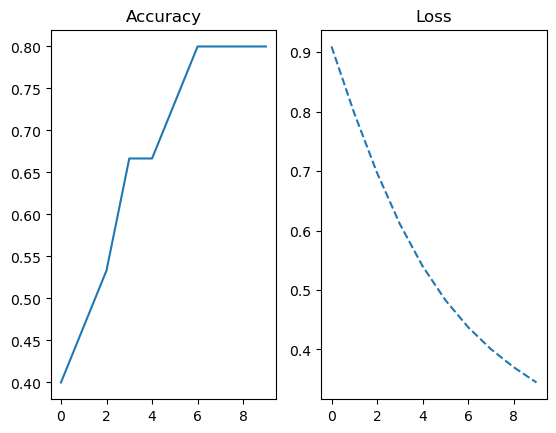

In [56]:
Acc_list=[]
Loss_list=[]
import matplotlib.pyplot as plt
figure,axs=plt.subplots(1,2)
def train(net, dataloader, val_x, val_lab, epochs=10, lr=0.05):
  optim = torch.optim.Adam(net.parameters(),lr=lr)
  for ep in range(epochs):
    for (x,y) in dataloader:
      z = net(x).flatten()
      loss = torch.nn.functional.binary_cross_entropy_with_logits(z,y)
      optim.zero_grad()
      loss.backward()
      optim.step()
    acc = ((torch.sigmoid(net(val_x).flatten())>0.5).float()==val_lab).float().mean()
    Acc_list.append(acc)
    Loss_list.append(loss.item())
    print(f"Epoch {ep}: last batch loss = {loss}, val acc = {acc}")
  epoch = list(range(epochs))
  axs[0].plot(Acc_list,label='Accuracy')
  axs[0].set_title('Accuracy')
  axs[1].plot(Loss_list, ls='--',label='Loss')
  axs[1].set_title('Loss')
  plt.show()

net = torch.nn.Linear(2,1)

train(net,dataloader,val_x,val_lab,lr=0.03)

## 定义网络为层的序列

现在让我们训练一个多层感知机。它可以通过指定一系列层来定义。生成的对象将自动继承自 `Module`，例如，它也会拥有 `parameters` 方法，该方法将返回整个网络的所有参数。


In [ ]:
net = torch.nn.Sequential(torch.nn.Linear(2,5),torch.nn.Sigmoid(),torch.nn.Linear(5,1))
print(net)

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=5, out_features=1, bias=True)
)


我们可以使用我们上面定义的函数 `train` 来训练这个多层网络：


In [ ]:
train(net,dataloader,val_x,val_lab)

Epoch 0: last batch loss = 0.5835739970207214, val acc = 0.800000011920929
Epoch 1: last batch loss = 0.4642275869846344, val acc = 0.800000011920929
Epoch 2: last batch loss = 0.35158076882362366, val acc = 0.800000011920929
Epoch 3: last batch loss = 0.26132312417030334, val acc = 0.800000011920929
Epoch 4: last batch loss = 0.19465585052967072, val acc = 0.800000011920929
Epoch 5: last batch loss = 0.14735405147075653, val acc = 0.800000011920929
Epoch 6: last batch loss = 0.11454981565475464, val acc = 0.800000011920929
Epoch 7: last batch loss = 0.09244414418935776, val acc = 0.800000011920929
Epoch 8: last batch loss = 0.07805468142032623, val acc = 0.800000011920929
Epoch 9: last batch loss = 0.06894762068986893, val acc = 0.800000011920929


## 将网络定义为一个类

使用继承自 `torch.nn.Module` 的类是一种更灵活的方法，因为我们可以在其中定义任何计算。`Module` 自动化了许多操作，例如，它会自动识别所有内部变量中属于 PyTorch 层的部分，并收集它们的参数以供优化使用。你只需要将网络的所有层定义为类的成员即可：


In [38]:
class MyNet(torch.nn.Module):
  def __init__(self,hidden_size=10,func=torch.nn.Sigmoid()):
    super().__init__()
    self.fc1 = torch.nn.Linear(2,hidden_size)
    self.func = func
    self.fc2 = torch.nn.Linear(hidden_size,1)

  def forward(self,x):
    x = self.fc1(x)
    x = self.func(x)
    x = self.fc2(x)
    return x
  
net = MyNet(func=torch.nn.ReLU())
print(net)

MyNet(
  (fc1): Linear(in_features=2, out_features=10, bias=True)
  (func): ReLU()
  (fc2): Linear(in_features=10, out_features=1, bias=True)
)


In [39]:
train(net,dataloader,val_x,val_lab,lr=0.005)

Epoch 0: last batch loss = 0.6356068253517151, val acc = 0.5333333611488342
Epoch 1: last batch loss = 0.6046009659767151, val acc = 0.6666666865348816
Epoch 2: last batch loss = 0.5737226605415344, val acc = 0.800000011920929
Epoch 3: last batch loss = 0.5434657335281372, val acc = 0.800000011920929
Epoch 4: last batch loss = 0.5144380331039429, val acc = 0.8666666746139526
Epoch 5: last batch loss = 0.4859374463558197, val acc = 0.8666666746139526
Epoch 6: last batch loss = 0.45802509784698486, val acc = 0.8666666746139526
Epoch 7: last batch loss = 0.43075069785118103, val acc = 0.800000011920929
Epoch 8: last batch loss = 0.4042564332485199, val acc = 0.800000011920929
Epoch 9: last batch loss = 0.37866783142089844, val acc = 0.800000011920929


**任务 1**：绘制训练过程中损失函数和准确率在训练数据和验证数据上的图表

**任务 2**：尝试使用此代码解决 MNIST 分类问题。提示：使用 `crossentropy_with_logits` 作为损失函数。


D:\Anaconda\envs\ai4beg\Lib\site-packages\torch\nn\modules\module.py:1736: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


0 0: last batch loss = 2.301320791244507, val acc = 0.140625
10 0: last batch loss = 1.7428920269012451, val acc = 0.78125
20 0: last batch loss = 1.6295145750045776, val acc = 0.8515625
30 0: last batch loss = 1.6202284097671509, val acc = 0.84375
40 0: last batch loss = 1.6028600931167603, val acc = 0.8671875
50 0: last batch loss = 1.627731442451477, val acc = 0.8125
60 0: last batch loss = 1.590131163597107, val acc = 0.875
70 0: last batch loss = 1.5798113346099854, val acc = 0.8828125
80 0: last batch loss = 1.5587233304977417, val acc = 0.90625
90 0: last batch loss = 1.5629231929779053, val acc = 0.890625
100 0: last batch loss = 1.5486830472946167, val acc = 0.90625
110 0: last batch loss = 1.5750330686569214, val acc = 0.890625
120 0: last batch loss = 1.5512644052505493, val acc = 0.9140625
130 0: last batch loss = 1.5426709651947021, val acc = 0.921875
140 0: last batch loss = 1.5458056926727295, val acc = 0.921875
150 0: last batch loss = 1.5597749948501587, val acc = 0.90

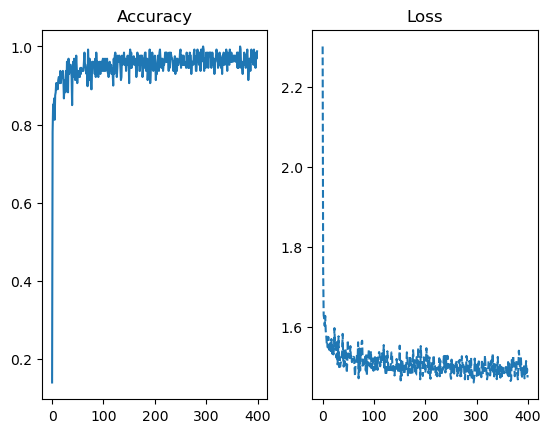

In [95]:
import gzip
import pickle
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class MnistNet(torch.nn.Module):
  def __init__(self,hidden_size=100,func=torch.nn.Sigmoid()):
    super().__init__()
    self.fc1 = torch.nn.Linear(784,hidden_size)
    self.func = torch.nn.ReLU()
    self.fc2 = torch.nn.Linear(hidden_size,10)
    self.func2=torch.nn.Softmax()

  def forward(self,x):
    x = self.fc1(x)
    x = self.func(x)
    x = self.fc2(x)
    x=self.func2(x)
    return x

net = MnistNet()
with gzip.open('../04-OwnFramework/lab/mnist.pkl.gz', 'rb') as f:
    mnist_tuple = pickle.load(f, encoding='latin1')  # encoding='latin1' 兼容旧版本保存的数据

MNIST = {
    'Train': {
        'Features': mnist_tuple[0][0],  # 训练集特征（X_train）
        'Labels': mnist_tuple[0][1]     # 训练集标签（y_train）
    },
    'Test': {
        'Features': mnist_tuple[1][0],  # 测试集特征（X_test）
        'Labels': mnist_tuple[1][1]     # 测试集标签（y_test）
    },
    'Validation': {  # 原数据集通常包含验证集，可选保留
        'Features': mnist_tuple[2][0],
        'Labels': mnist_tuple[2][1]
    }
}

class MNISTDataset(Dataset):
    def __init__(self, features, labels, transform=None):
        # 转换为 float32 张量（神经网络通常使用 float32）
        self.features = torch.tensor(features, dtype=torch.float32)
        # 标签转换为长整数张量（分类任务标签常用 int64）
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.transform = transform  # 可选：数据增强（如标准化）

    def __len__(self):
        # 返回数据集大小
        return len(self.features)

    def __getitem__(self, idx):
        # 根据索引返回单个样本（特征+标签）
        x = self.features[idx]
        y = self.labels[idx]
        # 若有转换函数（如标准化），应用到特征上
        if self.transform:
            x = self.transform(x)
        return x, y

X_train = MNIST['Train']['Features']  # 训练集特征（形状：(n_samples, 784)）
y_train = MNIST['Train']['Labels']    # 训练集标签（形状：(n_samples,)）
X_test = MNIST['Test']['Features']    # 测试集特征
y_test = MNIST['Test']['Labels']
train_dataset = MNISTDataset(X_train, y_train)
test_dataset = MNISTDataset(X_test, y_test)
batch_size=128

train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Acc_list=[]
Loss_list=[]
import matplotlib.pyplot as plt
figure,axs=plt.subplots(1,2)
def train(net, dataloader, epochs=10, lr=0.05):
  optim = torch.optim.Adam(net.parameters(),lr=lr)
  for ep in range(epochs):
    step=0
    for (x,y) in dataloader:
      z = net(x)
      loss_func = torch.nn.CrossEntropyLoss()
      loss=loss_func(z,y)
      optim.zero_grad()
      loss.backward()
      optim.step()
      if step%10==0:
        acc = ((torch.argmax(z, dim=1) == y).float().mean())
        Acc_list.append(acc)
        Loss_list.append(loss.item())
        print(f"{ step} {ep}: last batch loss = {loss}, val acc = {acc}")
      step+=1

    print(f"Epoch {ep}: last batch loss = {loss}, val acc = {acc}")
  axs[0].plot(Acc_list,label='Accuracy')
  axs[0].set_title('Accuracy')
  axs[1].plot(Loss_list, ls='--',label='Loss')
  axs[1].set_title('Loss')
  plt.show()

train(net,train_loader,lr=0.01)


让我们将编写的PyTorch模型代码包装在PyTorch Lightning模块中。这使您可以更方便和灵活地使用各种Lightning方法进行训练和准确性测试。


首先，我们需要安装并导入 PyTorch Lightning。这可以通过以下命令完成：

```
pip install pytorch-lightning
```  
或者  
```
conda install -c conda-forge pytorch-lightning
```


In [81]:
import pytorch_lightning as pl

为了让我们的代码在 Lightning 中正常运行，我们需要完成以下步骤：

1. 创建一个 `pl.LightningModule` 的子类，并在 `__init__` 方法中添加模型架构，同时实现 `forward` 方法。
2. 将使用的优化器移至 `configure_optimizers()` 方法中。
3. 分别在 `training_step` 和 `validation_step` 方法中定义训练和验证过程。
4. （可选）实现测试过程（`test_step` 方法）和预测过程（`predict_step` 方法）。

还需要注意的是，PyTorch Lightning 内置了模型在不同设备之间的自动转换功能，这取决于来自 `DataLoaders` 的输入数据所在的位置。因此，代码中所有 `.cuda()` 或 `.to(device)` 的调用都应该被移除。


In [93]:
class MyNetPL(pl.LightningModule):
    def __init__(self, hidden_size = 100, func = torch.nn.Sigmoid()):
        super().__init__()
        self.fc1 = torch.nn.Linear(2,hidden_size)
        self.func = func
        self.fc2 = torch.nn.Linear(hidden_size,1)

        self.val_epoch_num = 0 # for logging

    def forward(self, x):
        x = self.fc1(x)
        x = self.func(x)
        x = self.fc2(x)
        return x

    def training_step(self, batch, batch_nb):
        x, y = batch
        y_res = self(x).view(-1)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(y_res, y)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr = 0.01)
        return optimizer
    
    def validation_step(self, batch, batch_nb):
        x, y = batch
        y_res = self(x).view(-1)
        val_loss = torch.nn.functional.binary_cross_entropy_with_logits(y_res, y)
        print("Epoch ", self.val_epoch_num, ": val loss = ", val_loss.item(), " val acc = ",((torch.sigmoid(y_res.flatten())>0.5).float()==y).float().mean().item(),  sep = "")
        self.val_epoch_num += 1

让我们也添加验证`Dataset`和`DataLoader`：


In [80]:
valid_dataset = torch.utils.data.TensorDataset(torch.tensor(valid_x),torch.tensor(valid_labels,dtype=torch.float32))
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, batch_size = 16)

现在我们的模型已准备好进行训练。在 Pytorch Lightning 中，这个过程是通过 `Trainer` 类的对象实现的，它本质上将模型与任何数据集“混合”在一起。


In [96]:
net = MyNetPL(func=torch.nn.ReLU())
trainer = pl.Trainer(max_epochs = 30, log_every_n_steps = 1, accelerator='cpu', devices=1)
trainer.fit(model = net, train_dataloaders = dataloader, val_dataloaders = valid_dataloader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name | Type   | Params | Mode 
----------------------------------------
0 | fc1  | Linear | 30     | train
1 | func | ReLU   | 0      | train
2 | fc2  | Linear | 11     | train
----------------------------------------
41        Trainable params
0         Non-trainable params
41        Total params
0.000     Total estimated model params size (MB)
3         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0: val loss = 0.6610111594200134 val acc = 0.6666666865348816


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 29: val loss = 0.36666858196258545 val acc = 0.800000011920929


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 30: val loss = 0.36680659651756287 val acc = 0.800000011920929


`Trainer.fit` stopped: `max_epochs=30` reached.


## 要点

* PyTorch 允许你在低层次上操作张量，提供了最大的灵活性。
* 有一些方便的工具可以处理数据，比如 Datasets 和 Dataloaders。
* 你可以使用 `Sequential` 语法定义神经网络架构，或者通过继承 `torch.nn.Module` 类来实现。
* 如果想用更简单的方法定义和训练网络，可以了解一下 PyTorch Lightning。



---

**免责声明**：  
本文档使用AI翻译服务[Co-op Translator](https://github.com/Azure/co-op-translator)进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。应以原文档的原始语言版本为权威来源。对于关键信息，建议使用专业人工翻译。我们对因使用此翻译而引起的任何误解或误读不承担责任。
